In [3]:
import os
import pandas as pd
from pathlib import Path

# Project paths (based on current working directory in VS Code/Jupyter)
PROJECT_ROOT = Path(os.getcwd()).resolve().parents[0]
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Load model data
model_path = DATA_PROCESSED_DIR / "model_data.csv"
model_df = pd.read_csv(model_path, parse_dates=["date"])

# Quick sanity checks
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Shape:", model_df.shape)
print("Columns:", model_df.columns.tolist())
print("Date range:", model_df["date"].min(), "to", model_df["date"].max())

model_df.head()

PROJECT_ROOT: C:\Users\milli\Desktop\CodeForGit\1BIProjects\portfolio-projects\StocksClassification
Shape: (1229, 150)
Columns: ['date', 'ret_AAPL', 'ret_AMZN', 'ret_MSFT', 'ret_VOO', 'ret_SPY', 'ret_AAPL_lag1', 'ret_AAPL_lag2', 'ret_AAPL_lag5', 'ret_AMZN_lag1', 'ret_AMZN_lag2', 'ret_AMZN_lag5', 'ret_MSFT_lag1', 'ret_MSFT_lag2', 'ret_MSFT_lag5', 'ret_VOO_lag1', 'ret_VOO_lag2', 'ret_VOO_lag5', 'ret_SPY_lag1', 'ret_SPY_lag2', 'ret_SPY_lag5', 'ret_diff_SPY_AAPL', 'ret_diff_SPY_AMZN', 'ret_diff_SPY_MSFT', 'ret_diff_SPY_VOO', 'ret_diff_SPY_AAPL_lag1', 'ret_diff_SPY_AAPL_lag2', 'ret_diff_SPY_AAPL_lag5', 'ret_diff_SPY_AMZN_lag1', 'ret_diff_SPY_AMZN_lag2', 'ret_diff_SPY_AMZN_lag5', 'ret_diff_SPY_MSFT_lag1', 'ret_diff_SPY_MSFT_lag2', 'ret_diff_SPY_MSFT_lag5', 'ret_diff_SPY_VOO_lag1', 'ret_diff_SPY_VOO_lag2', 'ret_diff_SPY_VOO_lag5', 'ret_diff_SPY_SPY_lag1', 'ret_diff_SPY_SPY_lag2', 'ret_diff_SPY_SPY_lag5', 'ret_AAPL_lag1.1', 'ret_AAPL_lag2.1', 'ret_AAPL_lag5.1', 'ret_AMZN_lag1.1', 'ret_AMZN_lag

,date,ret_AAPL,ret_AMZN,ret_MSFT,ret_VOO,ret_SPY,ret_AAPL_lag1,ret_AAPL_lag2,ret_AAPL_lag5,ret_AMZN_lag1,...,ret_diff_SPY_MSFT_lag1.2,ret_diff_SPY_MSFT_lag2.2,ret_diff_SPY_MSFT_lag5.2,ret_diff_SPY_VOO_lag1.2,ret_diff_SPY_VOO_lag2.2,ret_diff_SPY_VOO_lag5.2,ret_diff_SPY_SPY_lag1.2,ret_diff_SPY_SPY_lag2.2,ret_diff_SPY_SPY_lag5.2,up_next_day_AAPL
0,2021-03-09,0.040650,0.037568,0.028102,0.013990,0.014277,-0.041674,0.010739,-0.020894,-0.016167,...,-0.032455,0.007202,-0.027235,-0.019183,0.004057,-0.022012,-0.019256,0.004119,-0.022081,0
1,2021-03-10,-0.009167,-0.001701,-0.005817,0.006182,0.006225,0.040650,-0.041674,-0.024457,0.037568,...,0.021877,-0.024403,-0.033205,0.007766,-0.011130,-0.019423,0.008053,-0.011203,-0.019471,1
2,2021-03-11,0.016503,0.018298,0.020265,0.010557,0.010139,-0.009167,0.040650,-0.015812,-0.001701,...,-0.015956,0.017962,-0.013786,-0.003957,0.003851,-0.022459,-0.003914,0.004138,-0.022514,0
3,2021-03-12,-0.007626,-0.007740,-0.005820,0.001409,0.001347,0.016503,-0.009167,0.010739,0.018298,...,0.018918,-0.007164,0.020133,0.009210,0.004835,0.016988,0.008792,0.004878,0.017050,1
4,2021-03-15,0.024457,-0.002528,-0.003987,0.005795,0.005963,-0.007626,0.016503,-0.041674,-0.007740,...,-0.011783,0.014302,-0.024141,-0.004554,0.004593,-0.010869,-0.004617,0.004176,-0.010942,1


In [4]:
# --- Define target and feature set ---

# Pick target column (next-day up/down for AAPL)
TARGET_COL = "up_next_day_AAPL"

# All feature columns = everything except date and targets
exclude_prefixes = ["up_next_day_"]
feature_cols = [
    c for c in model_df.columns
    if c not in ["date", TARGET_COL] and not any(c.startswith(p) for p in exclude_prefixes)
]

print("Number of features:", len(feature_cols))
print("First 10 features:", feature_cols[:10])

# --- Time-based train/test split ---

# Choose split date: everything before this is train, on/after is test
split_date = model_df["date"].max() - pd.DateOffset(years=1)
print("Split date:", split_date)

train_mask = model_df["date"] < split_date
test_mask = model_df["date"] >= split_date

X_train = model_df.loc[train_mask, feature_cols]
y_train = model_df.loc[train_mask, TARGET_COL]

X_test = model_df.loc[test_mask, feature_cols]
y_test = model_df.loc[test_mask, TARGET_COL]

print("Train size:", X_train.shape[0], "rows")
print("Test size:", X_test.shape[0], "rows")

Number of features: 148
First 10 features: ['ret_AAPL', 'ret_AMZN', 'ret_MSFT', 'ret_VOO', 'ret_SPY', 'ret_AAPL_lag1', 'ret_AAPL_lag2', 'ret_AAPL_lag5', 'ret_AMZN_lag1', 'ret_AMZN_lag2']
Split date: 2025-01-28 00:00:00
Train size: 977 rows
Test size: 252 rows


In [ ]:
# --- Baseline classifier: always predict majority class ---

# Find majority class in training labels
class_counts = y_train.value_counts()
print("Class counts in y_train:")
print(class_counts)

majority_class = class_counts.idxmax()
print("Majority class:", majority_class)

# Predict majority class for all train and test rows
y_train_pred_baseline = pd.Series(majority_class, index=y_train.index)
y_test_pred_baseline = pd.Series(majority_class, index=y_test.index)

# Compute simple accuracy
baseline_train_accuracy = (y_train_pred_baseline == y_train).mean()
baseline_test_accuracy = (y_test_pred_baseline == y_test).mean()

print("Baseline train accuracy:", baseline_train_accuracy)
print("Baseline test accuracy:", baseline_test_accuracy)

Class counts in y_train:
up_next_day_AAPL
1    521
0    456
Name: count, dtype: int64
Majority class: 1
Baseline train accuracy: 0.5332650972364381
Baseline test accuracy: 0.5198412698412699


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Logistic Regression model ---

log_reg = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

# Fit on training data
log_reg.fit(X_train, y_train)

# Predict on train and test
y_train_pred_lr = log_reg.predict(X_train)
y_test_pred_lr = log_reg.predict(X_test)

# Compute metrics
lr_train_accuracy = accuracy_score(y_train, y_train_pred_lr)
lr_test_accuracy = accuracy_score(y_test, y_test_pred_lr)

lr_test_precision = precision_score(y_test, y_test_pred_lr, zero_division=0)
lr_test_recall = recall_score(y_test, y_test_pred_lr, zero_division=0)
lr_test_f1 = f1_score(y_test, y_test_pred_lr, zero_division=0)

print("Logistic Regression:")
print("  Train accuracy:", lr_train_accuracy)
print("  Test  accuracy:", lr_test_accuracy)
print("  Test  precision:", lr_test_precision)
print("  Test  recall:", lr_test_recall)
print("  Test  F1:", lr_test_f1)

Logistic Regression:
  Train accuracy: 0.5557830092118731
  Test  accuracy: 0.5
  Test  precision: 0.5102880658436214
  Test  recall: 0.9465648854961832
  Test  F1: 0.6631016042780749


c:\Users\milli\Desktop\CodeForGit\1BIProjects\portfolio-projects\StocksClassification\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.metrics import confusion_matrix

# --- Confusion matrix for Logistic Regression (test set) ---

cm = confusion_matrix(y_test, y_test_pred_lr, labels=[0, 1])
print("Confusion matrix (rows=true, cols=pred):")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nDetailed counts:")
print("TN (true 0 predicted 0):", tn)
print("FP (true 0 predicted 1):", fp)
print("FN (true 1 predicted 0):", fn)
print("TP (true 1 predicted 1):", tp)

Confusion matrix (rows=true, cols=pred):
[[  2 119]
 [  7 124]]

Detailed counts:
TN (true 0 predicted 0): 2
FP (true 0 predicted 1): 119
FN (true 1 predicted 0): 7
TP (true 1 predicted 1): 124


Here’s a short text block you can paste into your notebook/README and tweak later:

> On the held‑out test set (last ~1 year), a Logistic Regression model trained to predict AAPL’s next‑day up/down direction achieved about 50% accuracy, similar to a simple majority‑class baseline of ~52%. Precision was around 0.51, recall was high at about 0.95, and the F1 score was roughly 0.66, indicating the model correctly identified most “up” days but frequently misclassified “down” days as “up.” The confusion matrix (TN=2, FP=119, FN=7, TP=124) highlights this imbalance: the model is very aggressive in predicting “up,” which may be acceptable if missing up moves is more costly than mistakenly expecting them, but overall it does not provide a strong edge beyond the naive baseline.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Random Forest model ---

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Fit on training data
rf_clf.fit(X_train, y_train)

# Predict on train and test
y_train_pred_rf = rf_clf.predict(X_train)
y_test_pred_rf = rf_clf.predict(X_test)

# Compute metrics
rf_train_accuracy = accuracy_score(y_train, y_train_pred_rf)
rf_test_accuracy = accuracy_score(y_test, y_test_pred_rf)

rf_test_precision = precision_score(y_test, y_test_pred_rf, zero_division=0)
rf_test_recall = recall_score(y_test, y_test_pred_rf, zero_division=0)
rf_test_f1 = f1_score(y_test, y_test_pred_rf, zero_division=0)

print("Random Forest:")
print("  Train accuracy:", rf_train_accuracy)
print("  Test  accuracy:", rf_test_accuracy)
print("  Test  precision:", rf_test_precision)
print("  Test  recall:", rf_test_recall)
print("  Test  F1:", rf_test_f1)


Random Forest:
  Train accuracy: 1.0
  Test  accuracy: 0.5317460317460317
  Test  precision: 0.533678756476684
  Test  recall: 0.7862595419847328
  Test  F1: 0.6358024691358025


Here’s a short Random Forest summary you can paste into the notebook/README:

> As a second model, a Random Forest classifier with 200 trees trained on the same feature set achieved perfect accuracy on the training data (1.00), confirming a strong tendency to overfit. On the held‑out test period, performance was modestly better than the naive baseline, with accuracy around 0.53, precision about 0.53, recall about 0.79, and an F1 score near 0.64, indicating that the forest captured more “up” days than Logistic Regression but still offered only a limited edge over always predicting the majority class.

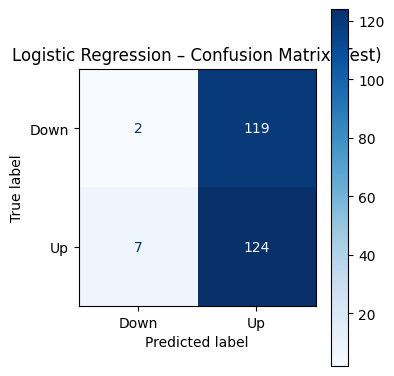

In [18]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Parent StocksClassification/reports/figures (no extra folder name)
PARENT = Path("..")          # -> ...\portfolio-projects\StocksClassification
FIG_DIR = PARENT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_lr,
    display_labels=["Down", "Up"],
    cmap=plt.cm.Blues,
    ax=ax
)
ax.set_title("Logistic Regression – Confusion Matrix (Test)")
plt.tight_layout()

fig_path_cm = FIG_DIR / "confusion_matrix_lr_test.png"
fig.savefig(fig_path_cm, dpi=150)
plt.show()


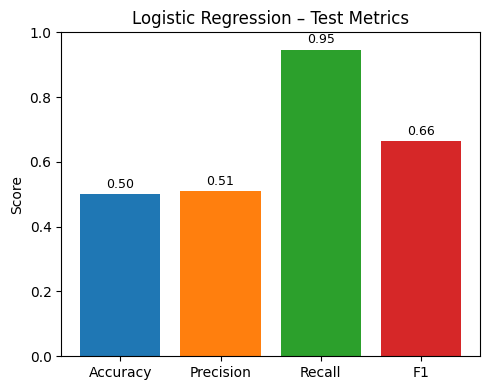

In [20]:
from pathlib import Path
import matplotlib.pyplot as plt

PARENT = Path("..")
FIG_DIR = PARENT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

metrics_names = ["Accuracy", "Precision", "Recall", "F1"]
metrics_values = [lr_test_accuracy, lr_test_precision, lr_test_recall, lr_test_f1]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(metrics_names, metrics_values, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Logistic Regression – Test Metrics")

for bar, value in zip(bars, metrics_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

fig_path_metrics = FIG_DIR / "lr_test_metrics.png"
fig.savefig(fig_path_metrics, dpi=150)
plt.show()
